# Download Baltic Sea velocity data

We use the [Copernicus Marine Service](https://marine.copernicus.eu/) Baltic Sea
physics analysis and forecast product (`cmems_mod_bal_phy_anfc_P1D-m`) to get
daily mean ocean current velocities.

For our drifter simulations, we only need the horizontal velocity components
(`uo`, `vo`) in the upper few metres. We download a single time snapshot and
cache it locally as a NetCDF file.

In [1]:
import copernicusmarine
import xarray as xr

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Open the remote dataset

This connects to the CMEMS data store lazily (no data is downloaded yet).

In [2]:
ds_remote = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_P1D-m",
    service="arco-geo-series",
)

ds_remote

INFO - 2026-03-18T15:56:11Z - Selected dataset version: "202411"


INFO - 2026-03-18T15:56:11Z - Selected dataset part: "default"


<xarray.Dataset> Size: 815GB
Dimensions:    (depth: 56, latitude: 774, longitude: 763, time: 1211)
Coordinates:
  * depth      (depth) float32 224B 0.5016 1.516 2.548 ... 663.9 688.0 712.0
  * latitude   (latitude) float32 3kB 53.01 53.02 53.04 ... 65.86 65.87 65.89
  * longitude  (longitude) float32 3kB 9.042 9.069 9.097 ... 30.15 30.18 30.21
  * time       (time) datetime64[ns] 10kB 2022-12-02 2022-12-03 ... 2026-03-26
Data variables:
    bottomT    (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    mlotst     (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    siconc     (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    sithick    (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float32 160GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    sob        (time, latitude, longitude) float32 3GB dask.array<chunksize=(100, 774, 763), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float32 160GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float32 160GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float32 160GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
    wo         (time, depth, latitude, longitude) float32 160GB dask.array<chunksize=(100, 2, 774, 763), meta=np.ndarray>
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

## Select and download a subset

We pick a single day (2025-07-01) and only the top 6 depth levels (~0–6 m),
keeping just the velocity components `uo` and `vo`. This brings the data down
from ~800 GB to ~27 MB.

In [3]:
ds_baltic = (
    ds_remote[["uo", "vo"]]
    .sel(time="2025-07-01", method="nearest")
    .isel(depth=slice(0, 6))
    .compute()
)

ds_baltic

<xarray.Dataset> Size: 28MB
Dimensions:    (depth: 6, latitude: 774, longitude: 763)
Coordinates:
  * depth      (depth) float32 24B 0.5016 1.516 2.548 3.602 4.684 5.8
  * latitude   (latitude) float32 3kB 53.01 53.02 53.04 ... 65.86 65.87 65.89
  * longitude  (longitude) float32 3kB 9.042 9.069 9.097 ... 30.15 30.18 30.21
    time       datetime64[ns] 8B 2025-07-01
Data variables:
    uo         (depth, latitude, longitude) float32 14MB nan nan nan ... nan nan
    vo         (depth, latitude, longitude) float32 14MB nan nan nan ... nan nan
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

## Save to disk

In [4]:
ds_baltic.drop_encoding().to_netcdf("ds_baltic.nc")

## Quick look

Current speed at each depth level, and the spatial pattern of surface-to-depth
shear near Kiel Bight.

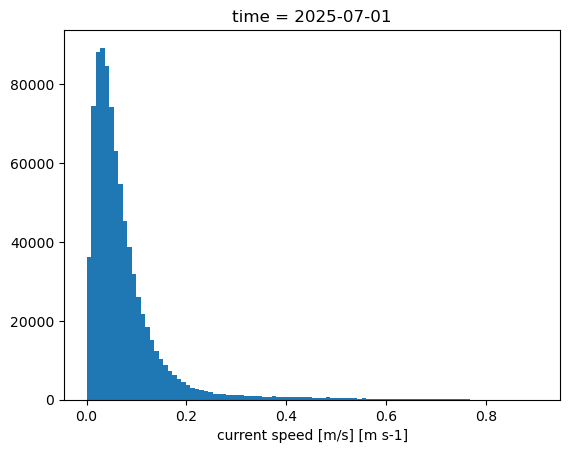

In [5]:
ds_baltic = xr.open_dataset("ds_baltic.nc")

spd = (ds_baltic.uo**2 + ds_baltic.vo**2) ** 0.5
spd = spd.where(spd > 0).rename("current speed [m/s]")

spd.plot.hist(bins=100);

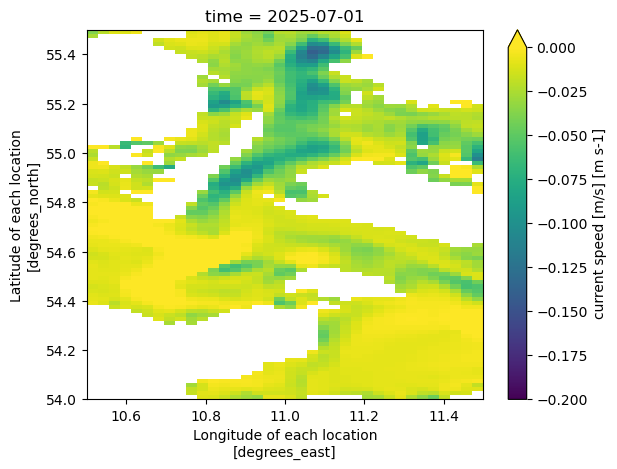

In [6]:
(spd.isel(depth=2) - spd.isel(depth=0)).sel(
    longitude=slice(10.5, 11.5), latitude=slice(54, 55.5)
).plot(vmin=-0.2, vmax=0);